# Proyecto 7: ViT con cambio de patch size

## Objetivo

Comprender cómo un **Vision Transformer (ViT)** convierte una imagen en una secuencia de *tokens* visuales y luego la clasifica usando el mecanismo de **self-attention**.

El flujo conceptual completo es:


$$
\text{Imagen}_{H \times W \times C}
\xrightarrow{\text{división en patches}}
\{p_1, p_2, \ldots, p_N\}
\xrightarrow{\text{flatten + proyección lineal}}
\{e_1, e_2, \ldots, e_N\}
\xrightarrow{\text{[class] + pos. emb.}}
\text{Transformer}
\xrightarrow{\text{MLP head}}
\hat{y}
$$


La **variante** que se analiza es el **cambio del tamaño de patch**: un patch pequeño genera más tokens (secuencia más larga y más costosa) pero captura más detalle; un patch grande genera menos tokens (secuencia corta y más barata) pero pierde resolución espacial.

## Sección 1: Importaciones y Configuración

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
import torchvision
import torchvision.transforms as transforms
from collections import Counter

import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
from pathlib import Path
from collections import OrderedDict
from tqdm import tqdm
import seaborn as sns
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [49]:
class ViTConfig:
    # Parámetros de imagen y patches
    image_size = 32
    large_patch_size = 8
    small_patch_size = 4
    large_num_patches = (image_size//large_patch_size) ** 2
    small_num_patches = (image_size//small_patch_size) ** 2
    large_patch_dim = large_patch_size ** 2 * 3
    small_patch_dim = small_patch_size ** 2 * 3
    
    # Parámetros del modelo
    embed_dim = 192
    num_heads = 6                 # Número de cabeceras de atención
    num_layers = 12                # Número de bloques transformer
    mlp_dim = 768                 # Dimensión interna de MLP (4x embed_dim)
    dropout = 0.1                  # Tasa de dropout
    attention_dropout = 0.0        # Dropout en atención
    
    # Parámetros de entrenamiento
    num_classes = 3
    batch_size = 128
    num_epochs = 20
    learning_rate = 1e-3
    weight_decay = 0.05
    warmup_epochs = 5
    
    # Para ablación
    use_class_token = True         # Usar token [class]
    use_pos_encoding = True        # Usar codificación posicional
    pooling_method = 'class'       # 'class' o 'mean'

config = ViTConfig()

print(f"Configuración ViT:")
print(f"  Tamaño imagen: {config.image_size}×{config.image_size}")
print(f"  Tamaño large_patch: {config.large_patch_size}×{config.large_patch_size}")
print(f"  Tamaño small_patch: {config.small_patch_size}×{config.small_patch_size}")
print(f"  Número de large_patches: {config.large_num_patches}")
print(f"  Número de small_patches: {config.small_num_patches}")
print(f"  Dimensión large_patch (aplanado): {config.large_patch_dim}")
print(f"  Dimensión smallpatch (aplanado): {config.small_patch_dim}")
print(f"  Dimensión embedding: {config.embed_dim}")

Configuración ViT:
  Tamaño imagen: 32×32
  Tamaño large_patch: 8×8
  Tamaño small_patch: 4×4
  Número de large_patches: 16
  Número de small_patches: 64
  Dimensión large_patch (aplanado): 192
  Dimensión smallpatch (aplanado): 48
  Dimensión embedding: 192


## Sección 2: Extracción y Aplanamiento de Patches

En esta etapa, la imagen se divide en pequeños bloques llamados patches y cada uno se transforma en un vector unidimensional mediante el proceso de flattening (IM2COL).

Una imagen $I$ de tamaño $H \times W \times C$ se divide en: 

$$N = \left(\frac{H}{P}\right) \times \left(\frac{W}{P}\right)$$ 

patches no superpuestos de tamaño:

$$P \times P \times C$$

**Ejemplo:** 
- Imagen: $32 \times 32 \times 3$ (RGB)
- Patch size: $4 \times 4$
- Número de patches: $(32/4)^2 = 64$ patches
- Cada patch: $4\times 4 \times 3 = 48$ elementos

Luego cada patch se **aplana** (flatten) en un vector de longitud 48.

In [50]:
def extract_patches(image, patch_size):
    """
    Extrae patches no superpuestos de una imagen.
    
    Args:
        image: tensor de forma (C, H, W) o (B, C, H, W)
        patch_size: tamaño del patch (int)
    
    Returns:
        patches: tensor de patches aplanados
    """
    # Si es imagen única, agregar dimensión batch
    if image.dim() == 3:
        image = image.unsqueeze(0)  # (B=1, C, H, W)

    #tamaño de la imagen
    B, C, H, W = image.shape
    
    # Usar unfold para extraer patches
    patches = image.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    # (B, C, H/patch_size, W/patch_size, patch_size, patch_size)

    patches = patches.contiguous().view(B, C, (H//patch_size), (W//patch_size), -1)
    # (B, C, num_patch_h, num_patch_w, patch_area)
    
    patches = patches.permute(0, 2, 3, 1, 4).contiguous()
     # (B, num_patch_h, num_patch_w, C, patch_area)
    
    patches = patches.view(B, (H // patch_size) * (W // patch_size), C * patch_size * patch_size)
    # (B, num_patches, patch_dim)
    
    return patches

# Demostración con una imagen CIFAR-10
print("Descargando CIFAR-10...")
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
])
cifar_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
print(f"\n{'='*60}")
demo_image, _ = cifar_data[0]

large_patches_demo = extract_patches(demo_image, config.large_patch_size)
print(f"Imagen original: {demo_image.shape}")
print(f"Patches extraídos: {large_patches_demo.shape}")
print(f"  Número de patches: {large_patches_demo.shape[1]}")
print(f"  Dimensión cada patch (aplanado): {large_patches_demo.shape[2]}")
print(f"\n{'='*60}")
small_patches_demo = extract_patches(demo_image, config.small_patch_size)
print(f"Imagen original: {demo_image.shape}")
print(f"Patches extraídos: {small_patches_demo.shape}")
print(f"  Número de patches: {small_patches_demo.shape[1]}")
print(f"  Dimensión cada patch (aplanado): {small_patches_demo.shape[2]}")

Descargando CIFAR-10...
Files already downloaded and verified

Imagen original: torch.Size([3, 32, 32])
Patches extraídos: torch.Size([1, 16, 192])
  Número de patches: 16
  Dimensión cada patch (aplanado): 192

Imagen original: torch.Size([3, 32, 32])
Patches extraídos: torch.Size([1, 64, 48])
  Número de patches: 64
  Dimensión cada patch (aplanado): 48


In [51]:
def visualize_patches(image, patch_size, title="Extracción de Patches"):
    """Visualiza cómo se divide una imagen en patches"""
    C, H, W = image.shape
    num_patch_h = H // patch_size
    num_patch_w = W // patch_size
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Imagen original
    img_rgb = image.permute(1, 2, 0).numpy()
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-5)
    axes[0].imshow(img_rgb)
    
    # Dibujar grid de patches
    for i in range(num_patch_h):
        axes[0].axhline(y=i*patch_size, color='red', linewidth=0.5)
    for j in range(num_patch_w):
        axes[0].axvline(x=j*patch_size, color='red', linewidth=0.5)
    axes[0].set_title(f"Imagen original ({H}×{W}) con grid de patches ({patch_size}×{patch_size})")
    axes[0].axis('off')
    
    patches = extract_patches(image, patch_size)  # (1, num_patches, patch_dim)
    patches = patches[0]  # (num_patches, patch_dim)
    
    patch_grid_shape = (num_patch_h, num_patch_w, patch_size, patch_size, C)
    patches_reshaped = patches.view(*patch_grid_shape)
    
    # Mostrar la grilla de patches
    axes[1].imshow(np.zeros((H, W, 3)), cmap='gray')
    axes[1].set_title(f"División en {num_patch_h*num_patch_w} patches")
    for i in range(num_patch_h):
        for j in range(num_patch_w):
            axes[1].add_patch(plt.Rectangle((j*patch_size, i*patch_size), 
                                            patch_size, patch_size, 
                                            fill=False, edgecolor='cyan', linewidth=1))
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

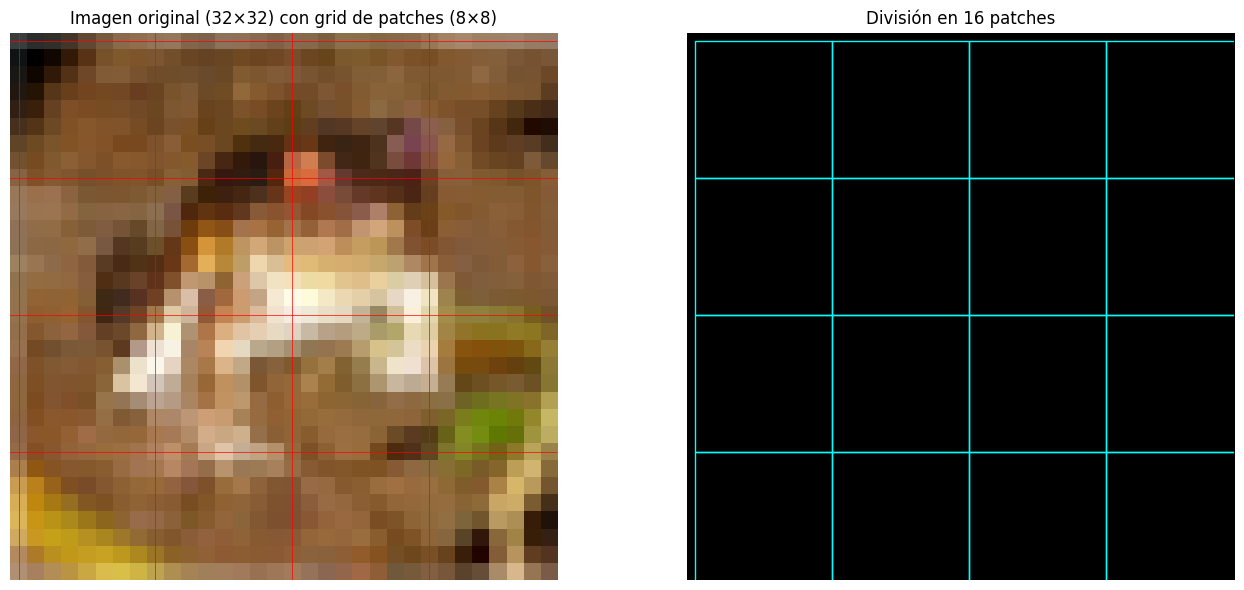

In [52]:
visualize_patches(demo_image, config.large_patch_size, title="Ejemplo: CIFAR-10 con patches de 4×4")

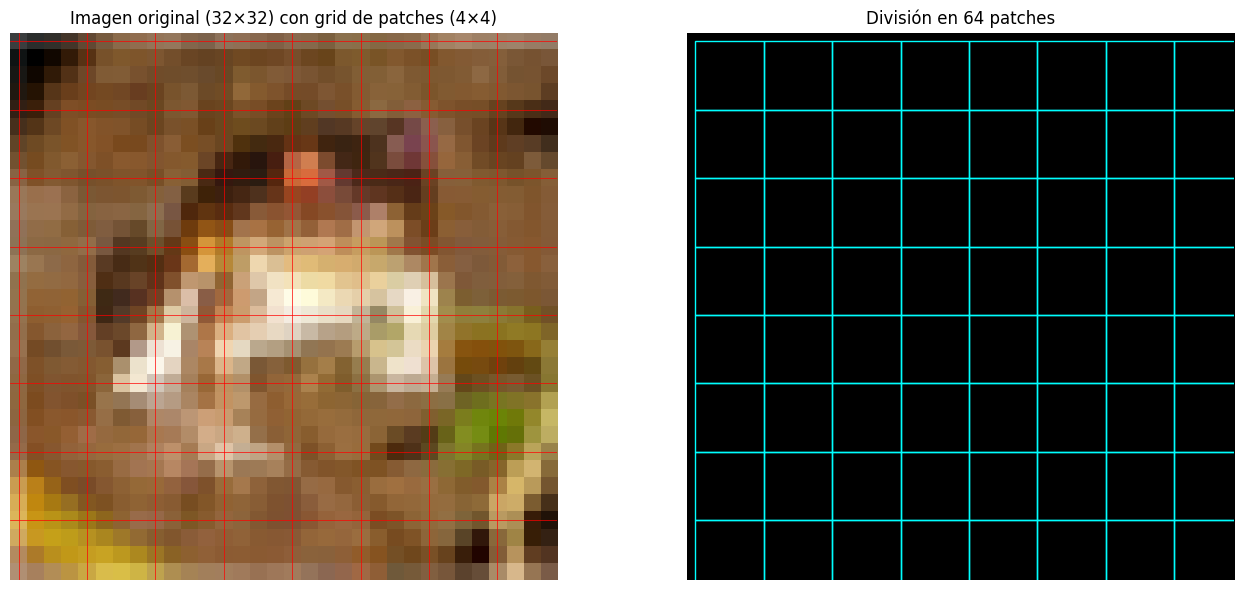

In [53]:
visualize_patches(demo_image, config.small_patch_size, title="Ejemplo: CIFAR-10 con patches de 4×4")

## Sección 3: Patch Embedding y Proyección Lineal

Después del proceso de flattening, cada patch se representa como un vector numérico. Sin embargo, estos vectores aún no tienen la dimensión requerida por el Transformer, por lo que se aplica una proyección lineal para convertir cada patch en un embedding aprendible dentro del espacio latente del modelo.

### Flujo de transformación:
1. Patch original: $4 \times 4 \times 3$
2. Patch aplanado: $\mathbb{R}^{P^2 \cdot C}$ (ej: 48)
3. Proyección lineal: $\mathbb{R}^{d_{model}}$ (ej: 192)
4. Embedding resultado: vector aprendible que representa al patch


La proyección se realiza mediante una capa lineal: 
$$E_{patch} = \text{Linear}(patch_{flat})$$

In [54]:
class PatchEmbedding(nn.Module):
    """
    Convierte una imagen en patches y los proyecta a embeddings.
    
    Arquitectura:
        Imagen (H×W×C) → Patches (N, P²C) → Embeddings (N, d_model)
    """
    
    def __init__(self, 
                 image_size: int,
                 patch_size: int,
                 in_channels: int,
                 embed_dim: int):
        super().__init__()
        
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = (patch_size ** 2) * in_channels
        
        # Capa lineal que proyecta patches aplanados a embeddings
        self.proj = nn.Linear(self.patch_dim, embed_dim)
        
    def forward(self, x):
        """
        Args:
            x: (B, C, H, W)
        Returns:
            patches_embed: (B, num_patches, embed_dim)
        """
        B, C, H, W = x.shape

        # Extraer patches
        patches = extract_patches(x, self.patch_size)

        # Proyectar a embeddings
        patch_embed = self.proj(patches)

        return patch_embed
      

In [55]:
# Demostración
large_patch_embedding = PatchEmbedding(
    image_size=config.image_size,
    patch_size=config.large_patch_size,
    in_channels=3,
    embed_dim=config.embed_dim
).to(device)

input_tensor = demo_image.unsqueeze(0).to(device)

output = large_patch_embedding(input_tensor)

print(f"Input shape: {input_tensor.shape}") # (1, 3, 32, 32)
print(f"Output patch embeddings shape: {output.shape}")
print(f"  Batch size: {output.shape[0]}")
print(f"  Número de patches: {output.shape[1]}")
print(f"  Dimensión embedding: {output.shape[2]}")

Input shape: torch.Size([1, 3, 32, 32])
Output patch embeddings shape: torch.Size([1, 16, 192])
  Batch size: 1
  Número de patches: 16
  Dimensión embedding: 192


In [56]:
# Demostración
small_patch_embedding = PatchEmbedding(
    image_size=config.image_size,
    patch_size=config.small_patch_size,
    in_channels=3,
    embed_dim=config.embed_dim
).to(device)

input_tensor = demo_image.unsqueeze(0).to(device)

output = small_patch_embedding(input_tensor)

print(f"Input shape: {input_tensor.shape}") # (1, 3, 32, 32)
print(f"Output patch embeddings shape: {output.shape}")
print(f"  Batch size: {output.shape[0]}")
print(f"  Número de patches: {output.shape[1]}")
print(f"  Dimensión embedding: {output.shape[2]}")

Input shape: torch.Size([1, 3, 32, 32])
Output patch embeddings shape: torch.Size([1, 64, 192])
  Batch size: 1
  Número de patches: 64
  Dimensión embedding: 192


## Sección 4: Token [class] y Codificación Posicional

Una vez obtenidos los embeddings de los patches, el modelo incorpora información adicional necesaria para que el Transformer pueda realizar correctamente la clasificación y conservar la estructura espacial de la imagen.

### Token [class]

Se agrega un token especial aprendible al inicio de la secuencia de patches::

$$\mathbf{z}_0 = [\text{token\_class}]$$

Este token se procesa a través del transformer y su salida final se usa para la predicción de clase.

**Propósito del token [class]**:
- Capturar información global de la imagen
- Facilitar la tarea de clasificación
- Actuar como una representación agregada de todos los patches
- Similar a un pooling contextual aprendido

### Codificación Posicional

El Transformer no posee noción inherente del orden o ubicación de los patches, por lo que es necesario añadir información sobre la posición espacial de cada uno dentro de la imagen.

Para ello, se utiliza una **codificación posicional sinusoidal**:

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

donde:

- $pos$ representa la posición del patch en la secuencia
- $i$ representa la dimensión del embedding
- $d_{model}$ es la dimensión total del embedding

Finalmente, la codificación posicional se suma al embedding de cada patch: 

$$E_{final} = E_{patch} + PE(pos)$$

In [57]:
class PositionalEncoding(nn.Module):
    """
    Codificación posicional sinusoidal para patches.
    
    Añade información de posición espacial a cada patch para que el modelo
    sepa dónde está cada parche en la imagen original.
    """
    
    def __init__(self, embed_dim: int, max_seq_len: int = 1000, dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.dropout = nn.Dropout(p=dropout)
        
        # Crear matriz de posiciones (max_seq_len, embed_dim)
        pe = torch.zeros(max_seq_len, embed_dim)
        # Se genera números 0,1,2,...,64 los cuales representan la posición de un patch
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        
        # Divisor para la fórmula sinusoidal
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * 
                            (-math.log(10000.0) / embed_dim))
        
        # Aplicar sin y cos alternados
        pe[:, 0::2] = torch.sin(position * div_term)
        if embed_dim % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        
        # Registrar buffer (no es parámetro entrenable)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_seq_len, embed_dim)
    
    def forward(self, x):
        """
        Args:
            x: (B, seq_len, embed_dim)
        Returns:
            x + positional_encoding
        """
        seq_len = x.shape[1]
        pos_enc = self.pe[:, :seq_len, :].to(x.device)
        x = x + pos_enc
        return self.dropout(x)

In [58]:
def add_class_token(patch_embeddings, embed_dim, batch_size, device):
    """
    Agrega el token [class] al inicio de la secuencia de patches.
    
    Args:
        patch_embeddings: (B, num_patches, embed_dim)
        embed_dim: dimensión del embedding
        batch_size: tamaño del batch
        device: dispositivo (CPU/GPU)
    
    Returns:
        sequence_with_class: (B, num_patches+1, embed_dim)
    """
    # Crear un token
    class_token = torch.randn(1, 1, embed_dim).to(device)
    #Expandir para cada elemento del batch
    class_token_expanded = class_token.expand(batch_size, 1, embed_dim)
    # Concatenar al inicio
    sequence_with_class = torch.cat([class_token_expanded, patch_embeddings], dim=1)

    return sequence_with_class, class_token
    

In [59]:
# Demostración - Large Patches
input_tensor = demo_image.unsqueeze(0).to(device)
large_patch_embeddings = large_patch_embedding(input_tensor)
large_seq_with_class, large_cls_token = add_class_token(large_patch_embeddings, config.embed_dim, large_patch_embeddings.shape[0], device)

print(f"Patches originales (large): {large_patch_embeddings.shape}")
print(f"Secuencia con [class] token: {large_seq_with_class.shape}")
print(f"  Token [class] forma: {large_cls_token.shape}")
print(f"\nNota: El token [class] se agregó al índice 0")
print(f"Ahora tenemos {large_seq_with_class.shape[1]} elementos en la secuencia")

Patches originales (large): torch.Size([1, 16, 192])
Secuencia con [class] token: torch.Size([1, 17, 192])
  Token [class] forma: torch.Size([1, 1, 192])

Nota: El token [class] se agregó al índice 0
Ahora tenemos 17 elementos en la secuencia


In [60]:
# Demostración - Small Patches
input_tensor = demo_image.unsqueeze(0).to(device)
small_patch_embeddings = small_patch_embedding(input_tensor)
small_seq_with_class, small_cls_token = add_class_token(small_patch_embeddings, config.embed_dim, small_patch_embeddings.shape[0], device)

print(f"Patches originales (small): {small_patch_embeddings.shape}")
print(f"Secuencia con [class] token: {small_seq_with_class.shape}")
print(f"  Token [class] forma: {small_cls_token.shape}")
print(f"\nNota: El token [class] se agregó al índice 0")
print(f"Ahora tenemos {small_seq_with_class.shape[1]} elementos en la secuencia")

Patches originales (small): torch.Size([1, 64, 192])
Secuencia con [class] token: torch.Size([1, 65, 192])
  Token [class] forma: torch.Size([1, 1, 192])

Nota: El token [class] se agregó al índice 0
Ahora tenemos 65 elementos en la secuencia


## Sección 5: Multi-Head Self-Attention para Visión

El mecanismo de self-attention permite que cada patch interactúe con todos los demás patches de la imagen para identificar qué regiones contienen información relevante. Gracias a esto, el modelo puede aprender relaciones globales entre diferentes partes de la imagen.

### Scaled Dot-Product Attention

Para cada patch, el Transformer genera tres representaciones:
- Query (Q): qué información busca el patch
- Key (K): qué información ofrece cada patch
- Value (V): información que será transmitida

La atención se calcula mediante:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

donde:

- $QK^T$ mide la similitud entre patches
- $\sqrt{d_k}$ estabiliza los valores numéricos
- $\text{softmax}$ convierte las similitudes en probabilidades de atención
- $V$ contiene la información contextual que será combinada

### Multi-Head Attention

En lugar de utilizar una sola atención, el modelo emplea múltiples cabeceras (heads) en paralelo:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

Cada cabecera aprende distintos patrones de atención, por ejemplo:

- relaciones espaciales cercanas,
- bordes y texturas,
- formas globales,
- o dependencias entre regiones distantes de la imagen.

In [61]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention para Vision Transformers.
    
    Permite que patches se atienten mutuamente, con múltiples cabeceras
    aprendiendo diferentes tipos de atención simultáneamente.
    """
    
    def __init__(self, embed_dim: int, num_heads: int, attn_drop: float = 0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        # Proyecciones: Q, K, V en una sola operación
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(attn_drop)
    
    def forward(self, x, return_attention_weights=False):
        """
        Args:
            x: (B, seq_len, embed_dim) - secuencia de embeddings (patches + [class])
            return_attention_weights: si True, retorna las matrices de atención
        
        Returns:
            out: (B, seq_len, embed_dim) - secuencia procesada por atención
            attn_weights: (B, num_heads, seq_len, seq_len) - si return_attention_weights=True
        """
        B, N, C = x.shape  # (batch, seq_len, embed_dim)
        
        # Proyectar Q, K, V
        qkv = self.qkv(x).reshape(B,N,3,self.num_heads,self.head_dim)
        qkv = qkv.permute(2,0,3,1,4)
        q, k , v = qkv[0], qkv[1], qkv[2]
        
        # Calcular scores: Q @ K^T / sqrt(d_k)
        scores = (q@k.transpose(-2,-1))*self.scale

        # Aplicar softmax
        attn_weights = F.softmax(scores, dim = -1)
        attn_weights = self.attn_drop(attn_weights)
        
        # Aplicar atención a values
        out = attn_weights @ v
        
        # Concatenar cabeceras
        out = out.transpose(1,2).reshape(B,N,C)

        # Proyección final
        out = self.proj(out)
        out = self.proj_drop(out)
        
        if return_attention_weights:
            return out, attn_weights
        return out


In [62]:
# Demostración - Large Patches with MultiHeadAttention
large_mha = MultiHeadAttention(embed_dim=config.embed_dim, num_heads=config.num_heads).to(device)

# Input: secuencia de patches
input_tensor = demo_image.unsqueeze(0).to(device)
large_patch_embeddings = large_patch_embedding(input_tensor)
large_seq_with_class, large_cls_token = add_class_token(large_patch_embeddings, config.embed_dim, large_patch_embeddings.shape[0], device)
large_output_mha, large_attn_weights = large_mha(large_seq_with_class, return_attention_weights=True)

print(f"Input shape: {large_seq_with_class.shape}")
print(f"Output shape: {large_output_mha.shape}")
print(f"Attention weights shape: {large_attn_weights.shape}")
print(f"  (batch={large_attn_weights.shape[0]}, heads={large_attn_weights.shape[1]}, seq_len={large_attn_weights.shape[2]}×{large_attn_weights.shape[3]})")
print(f"\nParámetros MultiHeadAttention: {sum(p.numel() for p in large_mha.parameters()):,}")

Input shape: torch.Size([1, 17, 192])
Output shape: torch.Size([1, 17, 192])
Attention weights shape: torch.Size([1, 6, 17, 17])
  (batch=1, heads=6, seq_len=17×17)

Parámetros MultiHeadAttention: 148,224


In [63]:
# Demostración - Small Patches with MultiHeadAttention
small_mha = MultiHeadAttention(embed_dim=config.embed_dim, num_heads=config.num_heads).to(device)

# Input: secuencia de patches
input_tensor = demo_image.unsqueeze(0).to(device)
small_patch_embeddings = small_patch_embedding(input_tensor)
small_seq_with_class, small_cls_token = add_class_token(small_patch_embeddings, config.embed_dim, small_patch_embeddings.shape[0], device)
small_output_mha, small_attn_weights = small_mha(small_seq_with_class, return_attention_weights=True)

print(f"Input shape: {small_seq_with_class.shape}")
print(f"Output shape: {small_output_mha.shape}")
print(f"Attention weights shape: {small_attn_weights.shape}")
print(f"  (batch={small_attn_weights.shape[0]}, heads={small_attn_weights.shape[1]}, seq_len={small_attn_weights.shape[2]}×{small_attn_weights.shape[3]})")
print(f"\nParámetros MultiHeadAttention: {sum(p.numel() for p in small_mha.parameters()):,}")

Input shape: torch.Size([1, 65, 192])
Output shape: torch.Size([1, 65, 192])
Attention weights shape: torch.Size([1, 6, 65, 65])
  (batch=1, heads=6, seq_len=65×65)

Parámetros MultiHeadAttention: 148,224


## Sección 6: Transformer Block - Add & Norm + FFN

Cada bloque transformer contiene:

1. **LayerNorm** → normaliza activaciones
2. **MultiHeadAttention** → auto-atención
3. **Residual Connection** → suma la entrada original (skip connection)
4. **LayerNorm** → normaliza nuevamente
5. **FeedForward (MLP)** → red neuronal posicional
6. **Residual Connection** → suma entrada

**Pre-Norm Architecture:**
$$x' = x + \text{MultiHeadAttention}(\text{LayerNorm}(x))$$
$$x'' = x' + \text{MLP}(\text{LayerNorm}(x'))$$

In [64]:
class TransformerBlock(nn.Module):
    """
    Bloque Transformer con Pre-Norm architecture.
    
    Flujo: x → LayerNorm → MHA → Residual → LayerNorm → MLP → Residual → output
    """
    
    def __init__(self, embed_dim: int, num_heads: int, mlp_dim: int, dropout: float = 0.1):
        super().__init__()
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.mha = MultiHeadAttention(embed_dim, num_heads, attn_drop=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        
        # FeedForward Network
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        """
        Args:
            x: (B, seq_len, embed_dim)
        
        Returns:
            out: (B, seq_len, embed_dim)
        """
        # Pre-Norm MHA branch
        x = x + self.mha(self.norm1(x))
        
        # Pre-Norm MLP branch
        x = x + self.mlp(self.norm2(x))
        
        return x


In [65]:
# Demostración - Large Patch
large_block = TransformerBlock(embed_dim=config.embed_dim, 
                         num_heads=config.num_heads, 
                         mlp_dim=config.mlp_dim).to(device)

input_tensor = demo_image.unsqueeze(0).to(device)
large_patch_embeddings = large_patch_embedding(input_tensor)
large_seq_with_class, large_cls_token = add_class_token(large_patch_embeddings, config.embed_dim, large_patch_embeddings.shape[0], device)

large_output_block = large_block(large_seq_with_class)

print(f"Input: {large_seq_with_class.shape}")
print(f"Output: {large_output_block.shape}")
print(f"Parámetros TransformerBlock (large): {sum(p.numel() for p in large_block.parameters()):,}")

Input: torch.Size([1, 17, 192])
Output: torch.Size([1, 17, 192])
Parámetros TransformerBlock (large): 444,864


In [66]:
# Demostración - Small Patch
small_block = TransformerBlock(embed_dim=config.embed_dim, 
                         num_heads=config.num_heads, 
                         mlp_dim=config.mlp_dim).to(device)

input_tensor = demo_image.unsqueeze(0).to(device)
small_patch_embeddings = small_patch_embedding(input_tensor)
small_seq_with_class, small_cls_token = add_class_token(small_patch_embeddings, config.embed_dim, small_patch_embeddings.shape[0], device)

small_output_block = small_block(small_seq_with_class)

print(f"Input: {small_seq_with_class.shape}")
print(f"Output: {small_output_block.shape}")
print(f"Parámetros TransformerBlock (small): {sum(p.numel() for p in small_block.parameters()):,}")

Input: torch.Size([1, 65, 192])
Output: torch.Size([1, 65, 192])
Parámetros TransformerBlock (small): 444,864


## Sección 7: Arquitectura Completa Vision Transformer

Ensamblamos todos los componentes:

```
Imagen (H×W×3)
    ↓
Patch Embedding (N, embed_dim)
    ↓
+ [class] token + Positional Encoding
    ↓
Stack de Transformer Blocks (N times)
    ↓
LayerNorm del [class] token
    ↓
Classification Head (MLP)
    ↓
Logits (num_classes)
```

In [67]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) completo para clasificación de imágenes.
    
    Implementa el flujo: Imagen → Patches → Embeddings → Transformer → Clasificación
    """
    
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.config = config
        
        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(
            image_size=config.image_size,
            patch_size=config.patch_size,
            in_channels=3,
            embed_dim=config.embed_dim
        )
        
        # 2. Token [class] (parámetro aprendible)
        self.class_token = nn.Parameter(torch.zeros(1, 1, config.embed_dim))
        
        # 3. Codificación posicional
        self.pos_encoding = PositionalEncoding(
            embed_dim=config.embed_dim,
            max_seq_len=config.num_patches + 1,  # +1 por [class]
            dropout=config.dropout
        )
        
        # 4. Stack de bloques transformer
        self.transformer = nn.Sequential(
            *[TransformerBlock(config.embed_dim, config.num_heads, 
                             config.mlp_dim, config.dropout) 
              for _ in range(config.num_layers)]
        )
        
        # 5. LayerNorm final
        self.norm = nn.LayerNorm(config.embed_dim)
        
        # 6. Cabecera de clasificación
        self.head = nn.Linear(config.embed_dim, config.num_classes)
        
        # Inicialización
        nn.init.trunc_normal_(self.class_token, std=0.02)
        self._init_weights()
    
    def _init_weights(self):
        """Inicialización de pesos típica para ViT"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.bias, 0)
                nn.init.constant_(m.weight, 1.0)
    
    def forward(self, x):
        """
        Args:
            x: (B, 3, 32, 32) - imagen
        
        Returns:
            logits: (B, num_classes) - predicciones
        """
        B = x.shape[0]
        
        # 1. Patch embedding
        patch_embed = self.patch_embed(x)
        
        # 2. Agregar [class] token
        class_token = self.class_token.expand(B,-1,-1)
        x = torch.cat([class_token, patch_embed], dim=1)
        
        # 3. Agregar posición
        x = self.pos_encoding(x)
        
        # 4. Transformer blocks
        x = self.transformer(x)
        
        # 5. LayerNorm
        x = self.norm(x)
        
        # 6. Tomar solo el [class] token para clasificación
        x = x[:,0]
        
        # 7. Cabecera de clasificación
        logits = self.head(x)
        
        return logits

In [68]:
from types import SimpleNamespace

config_dict = {k: v for k, v in ViTConfig.__dict__.items() if not k.startswith('__')}

large_patch_config = SimpleNamespace(
    **config_dict,
    patch_size=config.large_patch_size,
    num_patches=config.large_num_patches,
    patch_dim=config.large_patch_dim
)

small_patch_config = SimpleNamespace(
    **config_dict,
    patch_size=config.small_patch_size,
    num_patches=config.small_num_patches,
    patch_dim=config.small_patch_dim
)

In [74]:
# Crear modelo
large_vit_model = VisionTransformer(large_patch_config).to(device)

# Mostrar resumen
print(f"\n{'='*60}")
print(f"Vision Transformer Model Summary")
print(f"{'='*60}")
print(f"\nTotal parameters: {sum(p.numel() for p in large_vit_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in large_vit_model.parameters() if p.requires_grad):,}")

# Demostración con imagen 
x_demo = demo_image.unsqueeze(0).to(device)
with torch.no_grad():
    logits = large_vit_model(x_demo)

print(f"\nInput shape: {x_demo.shape}")
print(f"Output shape: {logits.shape}")


Vision Transformer Model Summary

Total parameters: 5,376,579
Trainable parameters: 5,376,579

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 3])


In [75]:
# Crear modelo
small_vit_model = VisionTransformer(small_patch_config).to(device)

# Mostrar resumen
print(f"\n{'='*60}")
print(f"Vision Transformer Model Summary")
print(f"{'='*60}")
print(f"\nTotal parameters: {sum(p.numel() for p in small_vit_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in small_vit_model.parameters() if p.requires_grad):,}")

# Demostración con imagen 
x_demo = demo_image.unsqueeze(0).to(device)
with torch.no_grad():
    logits = small_vit_model(x_demo)

print(f"\nInput shape: {x_demo.shape}")
print(f"Output shape: {logits.shape}")


Vision Transformer Model Summary

Total parameters: 5,348,931
Trainable parameters: 5,348,931

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 3])


## Sección 8: Preparación de Dataset y DataLoader

Usaremos **CIFAR-10**: 15,000 imágenes de 32×32 en 10 categorías.



In [73]:
selected_classes = ['airplane', 'automobile', 'bird']
# Índices reales en CIFAR-10
selected_class_ids = [0, 1, 2]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

# Descargar CIFAR-10
print("\nDescargando CIFAR-10...")
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)
full_test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_filtered_indices = []
test_filtered_indices = []
for idx, label in enumerate(full_train_dataset.targets):

    if label in selected_class_ids:
        train_filtered_indices.append(idx)

for idx, label in enumerate(full_test_dataset.targets):

    if label in selected_class_ids:
        test_filtered_indices.append(idx)

# 70% entrenamiento, 15% validación, 15% test
train_size = 700
val_size = 150
test_size = 150
random.seed(42)

random.shuffle(train_filtered_indices)
random.shuffle(test_filtered_indices)

train_indices = train_filtered_indices[:train_size]
val_indices = train_filtered_indices[
    train_size:train_size + val_size
]
test_indices = test_filtered_indices[:test_size]

train_subset = Subset(full_train_dataset, train_indices)

val_subset = Subset(full_train_dataset, val_indices)

test_subset = Subset(full_test_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=config.batch_size, shuffle=True, num_workers=0)

val_loader = DataLoader(val_subset, batch_size=config.batch_size, shuffle=False, num_workers=0)

test_loader = DataLoader(test_subset, batch_size=config.batch_size, shuffle=False, num_workers=0)

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
def count_classes(dataset_subset, dataset_name):
    labels = []
    for _, label in dataset_subset:
        labels.append(label)
    class_counts = Counter(labels)
    print(f"\n{dataset_name}")
    print("-" * 40)
    total = 0
    for class_id in selected_class_ids:
        class_name = cifar10_classes[class_id]
        count = class_counts[class_id]
        total += count
        print(f"{class_name:<15}: {count}")
    print("-" * 40)
    print(f"Total           : {total}")

print(f"\nResumen del Dataset Final")
print(f"{'-'*60}")

# Tabla de Distribución de Muestras
print(f"{'Split':<15} | {'Imágenes':<10} | {'Batches':<10}")
print(f"{'-'*45}")
print(f"{'Entrenamiento':<15} | {len(train_subset):<10} | {len(train_loader):<10}")
print(f"{'Validación':<15} | {len(val_subset):<10} | {len(val_loader):<10}")
print(f"{'Test':<15} | {len(test_subset):<10} | {len(test_loader):<10}")

print(f"\nParámetros de entrada:")
print(f"    > Batch Size: {config.batch_size}")
print(f"    > Image Size: {config.image_size}x{config.image_size}")

# Distribución detallada por clase
print(f"\nDistribución Detallada por Clase:")
count_classes(train_subset, "DISTRIBUCIÓN: ENTRENAMIENTO")
count_classes(val_subset, "DISTRIBUCIÓN: VALIDACIÓN")
count_classes(test_subset, "DISTRIBUCIÓN: TEST")



Descargando CIFAR-10...
Files already downloaded and verified
Files already downloaded and verified

Resumen del Dataset Final
------------------------------------------------------------
Split           | Imágenes   | Batches   
---------------------------------------------
Entrenamiento   | 700        | 6         
Validación      | 150        | 2         
Test            | 150        | 2         

Parámetros de entrada:
    > Batch Size: 128
    > Image Size: 32x32

Distribución Detallada por Clase:

DISTRIBUCIÓN: ENTRENAMIENTO
----------------------------------------
airplane       : 220
automobile     : 222
bird           : 258
----------------------------------------
Total           : 700

DISTRIBUCIÓN: VALIDACIÓN
----------------------------------------
airplane       : 53
automobile     : 52
bird           : 45
----------------------------------------
Total           : 150

DISTRIBUCIÓN: TEST
----------------------------------------
airplane       : 51
automobile     : 46
bird 

## Sección 9: Training Loop con Optimización y Scheduler

**Optimizador:** AdamW (Adam with weight decay)

**Scheduler:** Warmup + Cosine Annealing

**Loss:** CrossEntropyLoss

El scheduler aumenta el learning rate gradualmente (warmup) y luego lo reduce con coseno decreciente.

In [79]:
# Funciones de training y evaluación
def train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device, epoch):
    """Entrena una época"""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.num_epochs} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Estadísticas
        total_loss += loss.item()
        _, predicted = torch.max(outputs.detach(), 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100*total_correct/total_samples:.2f}%'
        })
    
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = total_correct / total_samples
    
    return epoch_loss, epoch_acc

def evaluate(model, val_loader, criterion, device):
    """Evalúa el modelo en validación o test"""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)
    
    epoch_loss = total_loss / len(val_loader)
    epoch_acc = total_correct / total_samples
    
    return epoch_loss, epoch_acc


In [80]:
# Configurar optimizador y scheduler
criterion = nn.CrossEntropyLoss()
large_optimizer = optim.AdamW(large_vit_model.parameters(), 
                        lr=large_patch_config.learning_rate,
                        weight_decay=large_patch_config.weight_decay)
small_optimizer = optim.AdamW(small_vit_model.parameters(), 
                        lr=small_patch_config.learning_rate,
                        weight_decay=small_patch_config.weight_decay)

# Scheduler: warmup + cosine annealing
warmup_steps = config.warmup_epochs * len(train_loader)
total_steps = config.num_epochs * len(train_loader)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return max(0.0, float(total_steps - current_step) / float(max(1, total_steps - warmup_steps)))

large_scheduler = optim.lr_scheduler.LambdaLR(large_optimizer, lr_lambda)
small_scheduler = optim.lr_scheduler.LambdaLR(small_optimizer, lr_lambda)

print(f"\nConfiguración de entrenamiento:")
print(f"  Epochs: {config.num_epochs}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Weight decay: {config.weight_decay}")
print(f"  Warmup epochs: {config.warmup_epochs}")
print(f"  Optimizer: AdamW")
print(f"  Scheduler: Warmup + Cosine Annealing")
print(f"  Device: {device}")


Configuración de entrenamiento:
  Epochs: 20
  Learning rate: 0.001
  Weight decay: 0.05
  Warmup epochs: 5
  Optimizer: AdamW
  Scheduler: Warmup + Cosine Annealing
  Device: cuda


In [84]:
# Almacenar historiales
large_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_counter = 0
patience = 5

print("\nIniciando entrenamiento...")
print("=" * 70)

try:
    for epoch in range(config.num_epochs):
        # Entrenamiento
        train_loss, train_acc = train_one_epoch(large_vit_model, train_loader, criterion, 
                                               large_optimizer, large_scheduler, device, epoch)
        large_history['train_loss'].append(train_loss)
        large_history['train_acc'].append(train_acc)
        
        # Validación
        val_loss, val_acc = evaluate(large_vit_model, val_loader, criterion, device)
        large_history['val_loss'].append(val_loss)
        large_history['val_acc'].append(val_acc)
        
        # Log
        print(f"\nEpoch {epoch+1}/{config.num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {100*train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {100*val_acc:.2f}%")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(large_vit_model.state_dict(), 'best_vit_model.pth')
            print(f"  ✓ Mejor modelo guardado (Acc: {100*val_acc:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping en epoch {epoch+1}")
                break
        
        print("=" * 70)

except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido por usuario")

# Cargar mejor modelo
large_vit_model.load_state_dict(torch.load('best_vit_model.pth'))
print("\nEntrenamiento completado.")


Iniciando entrenamiento...


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 22.73it/s]



Epoch 1/20:
  Train Loss: 0.6606 | Train Acc: 73.71%
  Val Loss:   0.7035 | Val Acc:   72.00%
  ✓ Mejor modelo guardado (Acc: 72.00%)


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 21.01it/s]



Epoch 2/20:
  Train Loss: 0.6506 | Train Acc: 72.29%
  Val Loss:   0.7596 | Val Acc:   72.00%


...


Epoch 8/20:
  Train Loss: 0.6202 | Train Acc: 74.14%
  Val Loss:   0.7809 | Val Acc:   68.67%


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 24.24it/s]



Epoch 9/20:
  Train Loss: 0.6770 | Train Acc: 72.29%
  Val Loss:   0.7313 | Val Acc:   69.33%


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 24.76it/s]



Epoch 10/20:
  Train Loss: 0.6422 | Train Acc: 73.14%
  Val Loss:   0.6753 | Val Acc:   69.33%

Early stopping en epoch 10

Entrenamiento completado.


In [85]:
# Almacenar historiales
small_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_counter = 0
patience = 5

print("\nIniciando entrenamiento...")
print("=" * 70)

try:
    for epoch in range(config.num_epochs):
        # Entrenamiento
        train_loss, train_acc = train_one_epoch(small_vit_model, train_loader, criterion, 
                                               small_optimizer, small_scheduler, device, epoch)
        small_history['train_loss'].append(train_loss)
        small_history['train_acc'].append(train_acc)
        
        # Validación
        val_loss, val_acc = evaluate(small_vit_model, val_loader, criterion, device)
        small_history['val_loss'].append(val_loss)
        small_history['val_acc'].append(val_acc)
        
        # Log
        print(f"\nEpoch {epoch+1}/{config.num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {100*train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {100*val_acc:.2f}%")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(small_vit_model.state_dict(), 'best_vit_model.pth')
            print(f"  ✓ Mejor modelo guardado (Acc: {100*val_acc:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping en epoch {epoch+1}")
                break
        
        print("=" * 70)

except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido por usuario")

# Cargar mejor modelo
small_vit_model.load_state_dict(torch.load('best_vit_model.pth'))
print("\nEntrenamiento completado.")


Iniciando entrenamiento...


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 16.40it/s]



Epoch 1/20:
  Train Loss: 1.1365 | Train Acc: 34.14%
  Val Loss:   1.0742 | Val Acc:   42.67%
  ✓ Mejor modelo guardado (Acc: 42.67%)


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 21.92it/s]



Epoch 2/20:
  Train Loss: 1.0776 | Train Acc: 41.29%
  Val Loss:   1.0092 | Val Acc:   41.33%


...


Epoch 9/20:
  Train Loss: 0.9065 | Train Acc: 58.57%
  Val Loss:   0.8834 | Val Acc:   54.67%


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 20.38it/s]



Epoch 10/20:
  Train Loss: 0.8989 | Train Acc: 60.57%
  Val Loss:   0.8889 | Val Acc:   56.67%


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 18.03it/s]



Epoch 11/20:
  Train Loss: 0.8849 | Train Acc: 60.43%
  Val Loss:   0.9143 | Val Acc:   56.67%

Early stopping en epoch 11

Entrenamiento completado.


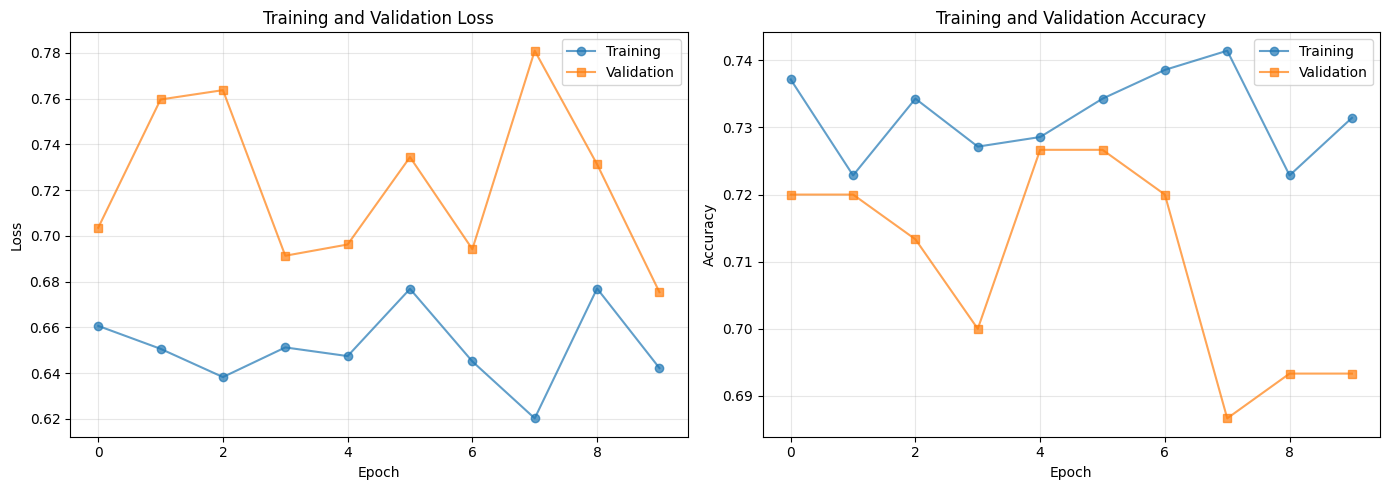


Evaluación en Test Set...


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 17.09it/s]

Test Loss: 0.6909
Test Accuracy: 72.67%

Muestrando predicciones...


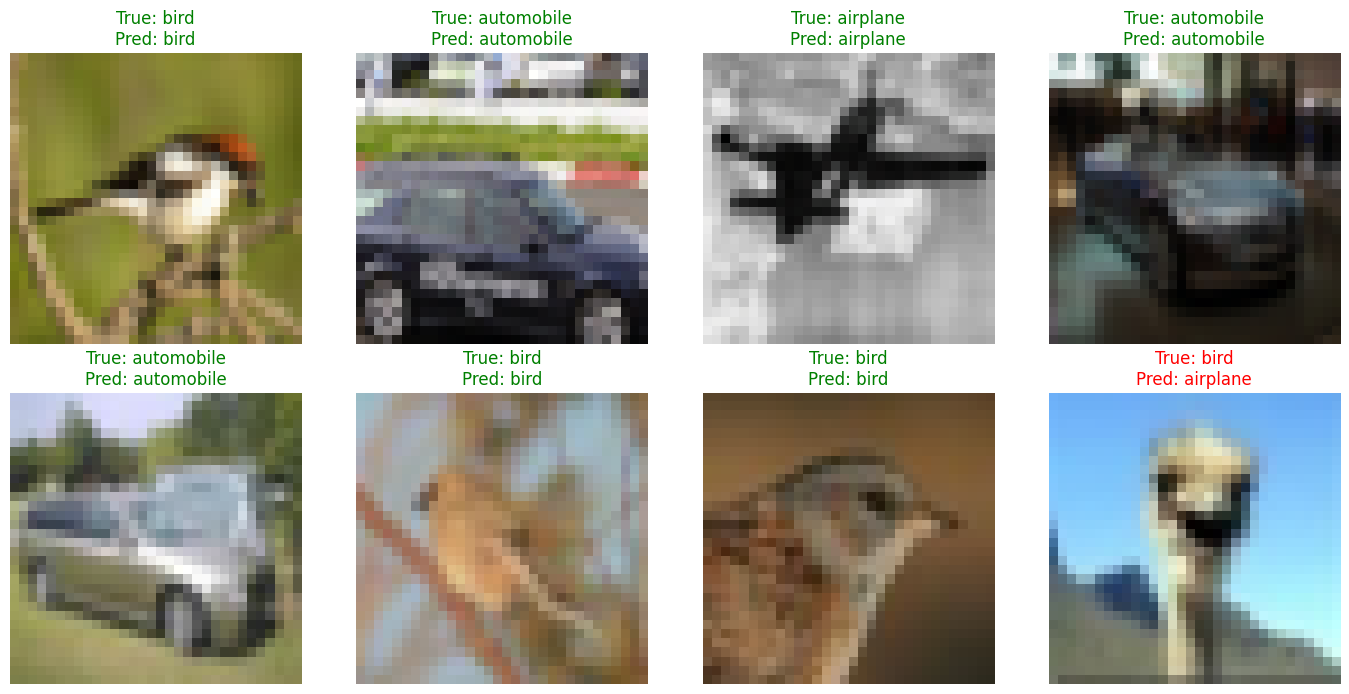

In [89]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(large_history['train_loss'], label='Training', marker='o', alpha=0.7)
axes[0].plot(large_history['val_loss'], label='Validation', marker='s', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precisión
axes[1].plot(large_history['train_acc'], label='Training', marker='o', alpha=0.7)
axes[1].plot(large_history['val_acc'], label='Validation', marker='s', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluación en test set
print("\nEvaluación en Test Set...")
test_loss, test_acc = evaluate(large_vit_model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {100*test_acc:.2f}%")

# Predicciones en muestra
print("\nMuestrando predicciones...")
batch_images, batch_labels = next(iter(test_loader))
batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

with torch.no_grad():
    outputs = large_vit_model(batch_images)
    _, predictions = torch.max(outputs, 1)

# Visualizar
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
classes = selected_classes

for i, ax in enumerate(axes.flat):
    img = batch_images[i].cpu()
    # Denormalizar
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1) + \
          torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1).permute(1, 2, 0)
    
    ax.imshow(img)
    true_label = classes[batch_labels[i]]
    pred_label = classes[predictions[i]]
    
    color = 'green' if predictions[i] == batch_labels[i] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

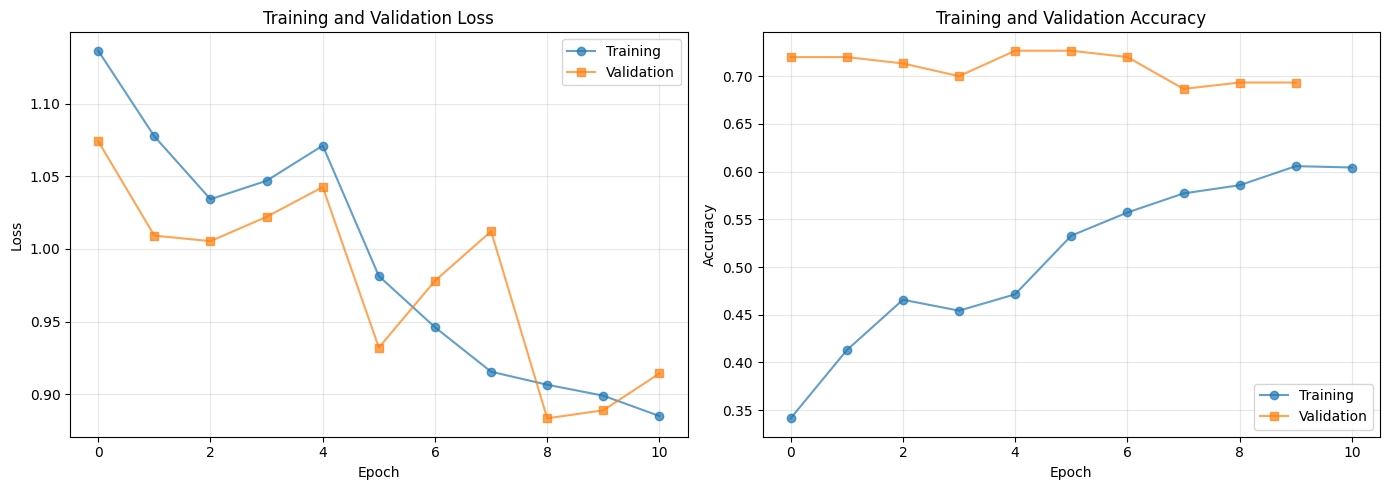


Evaluación en Test Set...


Evaluating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  8.78it/s]


Test Loss: 0.9204
Test Accuracy: 58.67%

Muestrando predicciones...


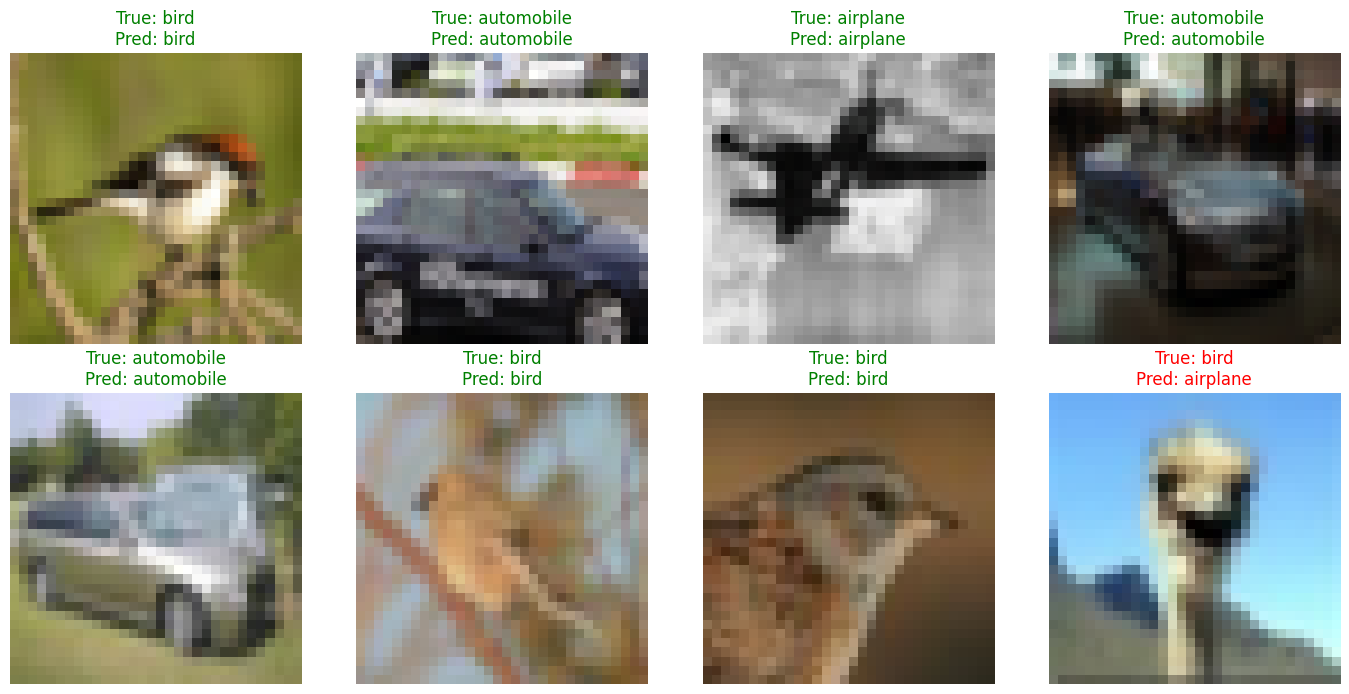

In [90]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(small_history['train_loss'], label='Training', marker='o', alpha=0.7)
axes[0].plot(small_history['val_loss'], label='Validation', marker='s', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precisión
axes[1].plot(small_history['train_acc'], label='Training', marker='o', alpha=0.7)
axes[1].plot(large_history['val_acc'], label='Validation', marker='s', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluación en test set
print("\nEvaluación en Test Set...")
test_loss, test_acc = evaluate(small_vit_model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {100*test_acc:.2f}%")

# Predicciones en muestra
print("\nMuestrando predicciones...")
batch_images, batch_labels = next(iter(test_loader))
batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

with torch.no_grad():
    outputs = large_vit_model(batch_images)
    _, predictions = torch.max(outputs, 1)

# Visualizar
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
classes = selected_classes

for i, ax in enumerate(axes.flat):
    img = batch_images[i].cpu()
    # Denormalizar
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1) + \
          torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1).permute(1, 2, 0)
    
    ax.imshow(img)
    true_label = classes[batch_labels[i]]
    pred_label = classes[predictions[i]]
    
    color = 'green' if predictions[i] == batch_labels[i] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Conclusiones

### Patch 8×8
Ventajas:
- Convergencia rápida.
- Mejor accuracy inicial.
- Menor costo computacional.

Desventajas:
- Entrenamiento inestable.
- Oscilaciones fuertes.
- Posible pérdida de detalles espaciales.
- Rápida saturación.
### Patch 4×4
Ventajas:
- Aprendizaje progresivo.
- Curvas más estables.
- Mejor representación espacial.
- Mayor capacidad de aprendizaje a largo plazo.

Desventajas:
- Entrenamiento más lento.
- Requiere más épocas y capacidad computacional.
- No alcanzó convergencia completa.


## Preguntas conceptuales

## 1. ¿Cómo se convierte una imagen en tokens?

Una imagen se convierte en tokens de la siguiente manera:

```
Imagen (H × W × C) 
    ↓ [División en patches no superpuestos]
Patches (N patches de tamaño P × P × C)
    ↓ [Aplanamiento - Flatten]
Vectores 1D (cada uno de dimensión P² × C)
    ↓ [Proyección lineal]
Embeddings (dimensión d_model = 192)
    ↓ [Agregar token [CLS] y posiciones]
Tokens listos para el Transformer (N+1 tokens)
```

---

## 2. ¿Qué representa cada patch?

Cada **patch es un bloque rectangular de píxeles** que representa una región local de la imagen.

Un patch 8×8 contiene más contexto visual porque cubre una región más grande.

Un patch 4×4 contiene más detalle fino porque cubre una región más pequeña.

---

## 3. ¿Qué hace flatten?

**Flatten** convierte una matriz multidimensional(patch) en un vector 1D:

```
Patch original (4 × 4 × 3):
┌─────────────────┐
│ R₁₁ R₁₂ R₁₃ R₁₄ │
│ R₂₁ R₂₂ R₂₃ R₂₄ │
│ ...             │
│ B₄₁ B₄₂ B₄₃ B₄₄ │
└─────────────────┘

    ↓ FLATTEN

Vector 1D (48 elementos):
[R₁₁, R₁₂, R₁₃, R₁₄, R₂₁, R₂₂, ..., G₄₄, B₄₄]
```

---

## 4. ¿Qué hace la proyección lineal?

La **proyección lineal transforma el vector aplanado del patch al espacio de embedding del modelo**:

$$\text{embedding} = W \cdot \text{patch\_flat} + b$$

Donde:
- $W$: matriz de pesos aprendibles (d_model × patch_dim)
- $b$: sesgo aprendible
- **Entrada**: Vector 1D de dimensión 48 (para patch 4×4)
- **Salida**: Vector de dimensión 192 (embedding_dim)

**Función**: 
- Reduce/expande dimensionalidad
- Mapea el espacio de píxeles al espacio latente del Transformer
- Los pesos se ajustan durante el entrenamiento para aprender representaciones útiles

---

## 5. ¿Para qué sirve el class token?

El **[CLS] token es un vector especial aprendible** que se agrega al inicio de la secuencia:

```
Secuencia original: [patch₁, patch₂, ..., patchₙ]
    ↓
Con [CLS]: [[CLS], patch₁, patch₂, ..., patchₙ]
```

**Funciones**:

1. **Agregación de información global**: 
   - El token [CLS] "interactúa" con todos los patches mediante self-attention
   - Al final, contiene información resumida de toda la imagen

2. **Clasificación**:
   - Solo se usa la representación final del [CLS] para clasificar
   - Es como un "resumen ejecutivo" de la imagen

3. **Analogía BERT**: 
   - Concepto tomado de NLP (BERT usa [CLS] para clasificación de textos)

**Salida del modelo**:
```
[CLS] actualizado → MLP head → logits → predicción
```

---

## 6. ¿Qué aporta el embedding posicional?

El **embedding posicional añade información de ubicación espacial** de cada patch:

```
Embedding patch = Embedding lineal del patch + Embedding posicional
```

**¿Por qué es necesario?**

Los Transformers no tienen estructura espacial inherente (procesan secuencias sin orden). Sin posiciones:
- Patch (0,0) y patch (15,15) son idénticos si tienen los mismos píxeles
- El modelo no sabría dónde está cada patch en la imagen

**Resultado**: El modelo entiende tanto QUÉ hay en cada patch como DÓNDE está ese patch en la imagen.

---

## 7. ¿Qué cambia cuando el patch es más grande?

Cambiar el tamaño del patch impacta **dramáticamente** el comportamiento:

| Aspecto | Patch 8×8 | Patch 4×4 |
|---------|-----------|-----------|
| **Número de patches** | 16 (4×4 grid) | 64 (8×8 grid) |
| **Dim. patch aplanado** | 192 (8²×3) | 48 (4²×3) |
| **Información/patch** | Baja resolución | Alta resolución |
| **Largo secuencia Transformer** | Corta (16+1) | Larga (256+1) |
| **Costo computacional** | Bajo | **Alto** (cuadrático) |
| **Captura de detalles** | Pierde bordes pequeños | Preserva texturas |
| **Generalización** | Ruidosa | Más confiable |

**Trade-off**: 
- Patches grandes = rápido pero impreciso
- Patches pequeños = lento pero más preciso

En nuestros resultados: **4×4 ganó porque CIFAR-10 es pequeño (32×32) y necesita resolución fina**.

---

## 8. ¿Dónde aparece el costo cuadrático de attention?

El costo cuadrático aparece en el **mecanismo de self-attention del Transformer**:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Análisis de complejidad**:

1. **Multiplicación matriz Q × K^T**:
   - Q: (N × d_k)
   - K^T: (d_k × N)
   - Resultado: (N × N) ← **CUADRÁTICO EN N**
   - Costo: O(N² · d_k)

2. **Aplicar softmax**: O(N²)

3. **Multiplicar por V**: O(N² · d_v)

**Ejemplo numérico**:
- Patch 8×8: N=16 → 16²=256 operaciones por cabecera
- Patch 4×4: N=256 → 256²=65,536 operaciones por cabecera ← **256x más**

**En el notebook**:
- Con 12 capas Transformer y 6 cabeceras de atención
- Patch 4×4: costo total ∝ 256² × 12 × 6 = **muy alto**
- Esto explica por qué tarda más el entrenamiento pero converge mejor

---

## 9. ¿Cómo conecta esto con Learner-ViT-Workbook.xlsx?

El archivo Learner-ViT-Workbook.xlsx mapea el flujo ViT:

```
IMAGEN (32×32)
    ↓
[Workbook muestra: División visual en patches]
    ↓
PATCHES → FLATTEN
    ↓
[Workbook muestra: Matriz aplanada, valores numéricos]
    ↓
PROYECCIÓN LINEAL (W × patch + b)
    ↓
[Workbook muestra: Fórmulas Excel, pesos aleatorios]
    ↓
[CLS] + POS_EMB
    ↓
[Workbook muestra: Embedding final, estructura secuencia]
    ↓
TRANSFORMER (Multi-head Attention)
    ↓
[Workbook muestra: Matriz de atención, cálculos QKV]
    ↓
MLP HEAD → LOGITS → PREDICCIÓN
    ↓
[Workbook muestra: Resultado final, comparación con label]
```